<a href="https://colab.research.google.com/github/shreyasantosh17/100_days_100_web_project/blob/Main/finalfrauddetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

df = pd.read_csv("PS_20174392719_1491204439457_log.csv")
print(df)

       step      type     amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0         1   PAYMENT    9839.64  C1231006815      170136.00       160296.36   
1         1   PAYMENT    1864.28  C1666544295       21249.00        19384.72   
2         1  TRANSFER     181.00  C1305486145         181.00            0.00   
3         1  CASH_OUT     181.00   C840083671         181.00            0.00   
4         1   PAYMENT   11668.14  C2048537720       41554.00        29885.86   
...     ...       ...        ...          ...            ...             ...   
56198     9  CASH_OUT   16024.60  C1088493558      442118.00       426093.40   
56199     9   PAYMENT   20502.92   C410885495        3073.00            0.00   
56200     9   CASH_IN  175858.36   C702220078      290164.69       466023.05   
56201     9   PAYMENT    2955.89  C1632500548      466023.05       463067.17   
56202     9    PAYMEN        NaN          NaN            NaN             NaN   

          nameDest  oldbalanceDest  new

In [ ]:
df = df[['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest',"isFraud",]]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56203 entries, 0 to 56202
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   amount          56202 non-null  float64
 1   oldbalanceOrg   56202 non-null  float64
 2   newbalanceOrig  56202 non-null  float64
 3   oldbalanceDest  56202 non-null  float64
 4   newbalanceDest  56202 non-null  float64
 5   isFraud         56202 non-null  float64
dtypes: float64(6)
memory usage: 2.6 MB


In [ ]:
df.isnull().sum()

,0
amount,1
oldbalanceOrg,1
newbalanceOrig,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [ ]:
df['amount'].dropna()
df['oldbalanceOrg'].dropna()
df['newbalanceOrig'].dropna()
df['oldbalanceDest'].dropna()
df['newbalanceDest'].dropna()
df['isFraud'].dropna(inplace=True)

In [ ]:
df.dropna(subset=['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud'], inplace=True)

X = df.drop('isFraud', axis=1)
y = df['isFraud']



In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=1)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
dt_pred=dt.predict(X_test)

In [ ]:
dt_accuracy=accuracy_score(y_test,dt_pred)

In [ ]:
print("accuracy of decision tree=",dt_accuracy)

accuracy of decision tree= 0.9981021291738331


In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression (solver='liblinear')
classifier.fit(X_train,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LogisticRegression(solver='liblinear')

In [ ]:
accuracy=accuracy_score(y_test,dt_pred)
print("accuracy",accuracy)

accuracy 0.9981021291738331


In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, dt_pred)  # Calculate accuracy
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00


<ipython-input-49-c3c71fa29455>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')


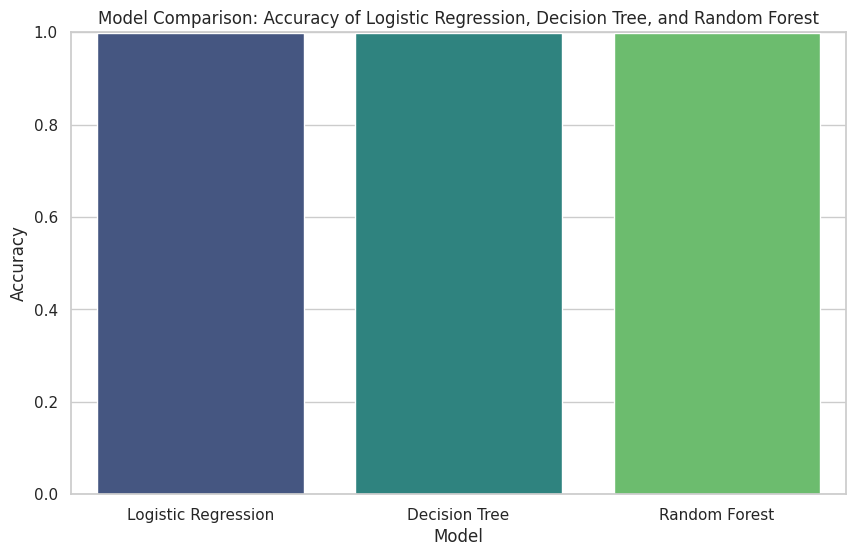

In [ ]:
# Set the style
import seaborn as sns
sns.set(style="whitegrid")
import matplotlib.pyplot as plt

# Create a dictionary to store the results
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test,y_predict), accuracy_score(y_test,dt_pred) , accuracy_score(y_test, dt_pred.astype(int))]  # Replace with your actual accuracy values
}

# Convert the dictionary to a DataFrame
results = pd.DataFrame(results)

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')

# Add title and labels
plt.title('Model Comparison: Accuracy of Logistic Regression, Decision Tree, and Random Forest')
plt.xlabel('Model')
plt.ylabel('Accuracy')

# Show the plot
plt.ylim(0, 1)  # Set y-axis limits
plt.show()

In [ ]:

from sklearn.metrics import accuracy_score
y_predict = classifier.predict(X_test)
print(accuracy_score(y_test,y_predict))


0.9989324476602811


In [ ]:
Results = pd.DataFrame({'A':y_test,'P':y_predict})
Results.head(10)

,A,P
45646,0.0,0.0
11602,0.0,0.0
31452,0.0,0.0
21075,0.0,0.0
19867,0.0,0.0
11494,0.0,0.0
36371,0.0,0.0
16733,0.0,0.0
46470,0.0,0.0
19183,0.0,0.0


In [ ]:
y_test_proba = classifier.predict_proba(X_test) # Calculate predicted probabilities
y_test_proba[0:5,:]

array([[9.70746693e-01, 2.92533069e-02],
       [1.00000000e+00, 7.22705767e-21],
       [6.56818127e-01, 3.43181873e-01],
       [1.00000000e+00, 0.00000000e+00],
       [1.00000000e+00, 1.27611503e-61]])

In [ ]:
import numpy as np
array_in_scientific = y_test_proba[0:5,:]
array_in_normal = np.vectorize(lambda x: format(x, '.16f'))(array_in_scientific)
print(array_in_normal)

[['0.9707466930517580' '0.0292533069482420']
 ['1.0000000000000000' '0.0000000000000000']
 ['0.6568181273867361' '0.3431818726132639']
 ['1.0000000000000000' '0.0000000000000000']
 ['1.0000000000000000' '0.0000000000000000']]


In [ ]:
T = y_test_proba[:,1]
array_in_one = T
S = np.vectorize(lambda x: format(x, '.16f'))(array_in_one)

print(S)

['0.0292533069482420' '0.0000000000000000' '0.3431818726132639' ...
 '0.1934261198848596' '0.0000000000000000' '0.0000000000000000']


In [ ]:
Results = pd.DataFrame({'Actual':y_test,'Predictions':y_predict,'Prob(Class = 1)':S})

Results.head(5)

,Actual,Predictions,Prob(Class = 1)
45646,0.0,0.0,0.0292533069482420
11602,0.0,0.0,0.0000000000000000
31452,0.0,0.0,0.3431818726132639
21075,0.0,0.0,0.0000000000000000
19867,0.0,0.0,0.0000000000000000


In [ ]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_predict)
print(cm)

[[16820     9]
 [    9    23]]


Text(95.72222222222221, 0.5, 'True Label')

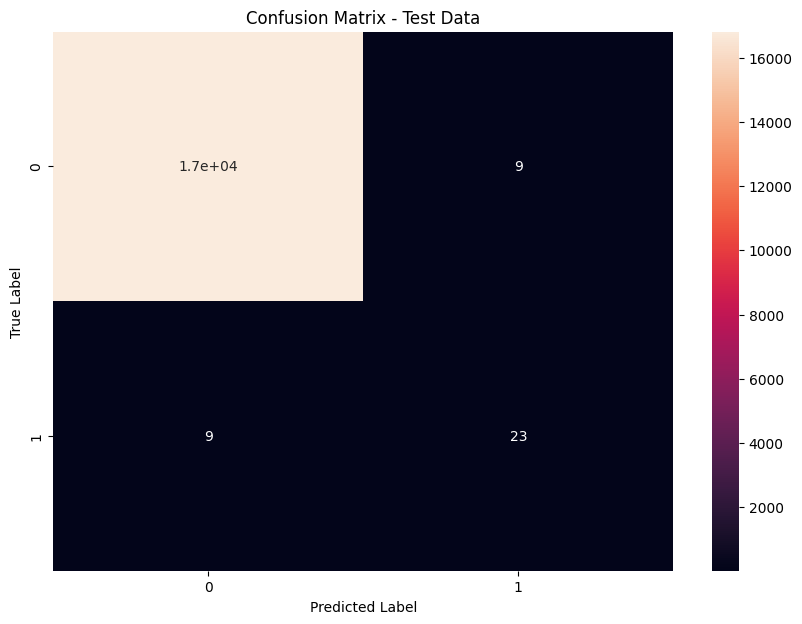

In [ ]:
import seaborn as sn
import matplotlib.pyplot as plt # Import matplotlib.pyplot

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.title('Confusion Matrix - Test Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

In [ ]:

def real_time_fraud_detection(model):
    print("Enter transaction details for fraud detection:")
    feature_names = ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

    input_data = []
    for feature in feature_names:
        value = input(f"Enter {feature}: ")
        try:
            value = float(value)
        except ValueError:
            pass
        input_data.append(value)


    input_array = np.array(input_data).reshape(1, -1)


    prediction = classifier.predict(input_array)


    if prediction[0] == 1:
        print("\n Fraudulent Transaction Detected!")
    else:
        print("\n Transaction is Safe.")


real_time_fraud_detection(classifier)

Enter transaction details for fraud detection:
Enter amount: 2000
Enter oldbalanceOrg: 4000
Enter newbalanceOrig: 1500
Enter oldbalanceDest: 200
Enter newbalanceDest: 1200

 Transaction is Safe.
